In [1]:
# only run this cell if LAGF is not installed
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from LAGF.trace_mass_process import read_mzmlfile
from LAGF.auto_min_peakheight import estimate_min_peak_height
from LAGF.extract_EIC_LAGF import extract_EIC_LAGF
from LAGF.peaks import Peaks

Read Mzml file

In [24]:
ms1, ms2, ms1_, mzml_path = read_mzmlfile()
print(mzml_path)

C:\Users\29156\Desktop\zss\LAGF\data\TCSP.mzML


Extract EIC

In [25]:
EIC = extract_EIC_LAGF(ms1_, traget_check=False,mz_tolerance=0.005,min_intensity=1000)
EIC.keys()

EIC Extraction:: 100%|██████████| 10000/10000 [00:11<00:00, 834.87it/s]


dict_keys(['rt_numbers', 'rt_times', 'tracks', 'mz_range'])

In [5]:
print("The file mz range: ",  EIC["mz_range"])

The file mz range:  [100.01110076904297, 1196.8253173828125]


Plot EIC 

Text(0.5, 1.0, 'mz= 183.0779')

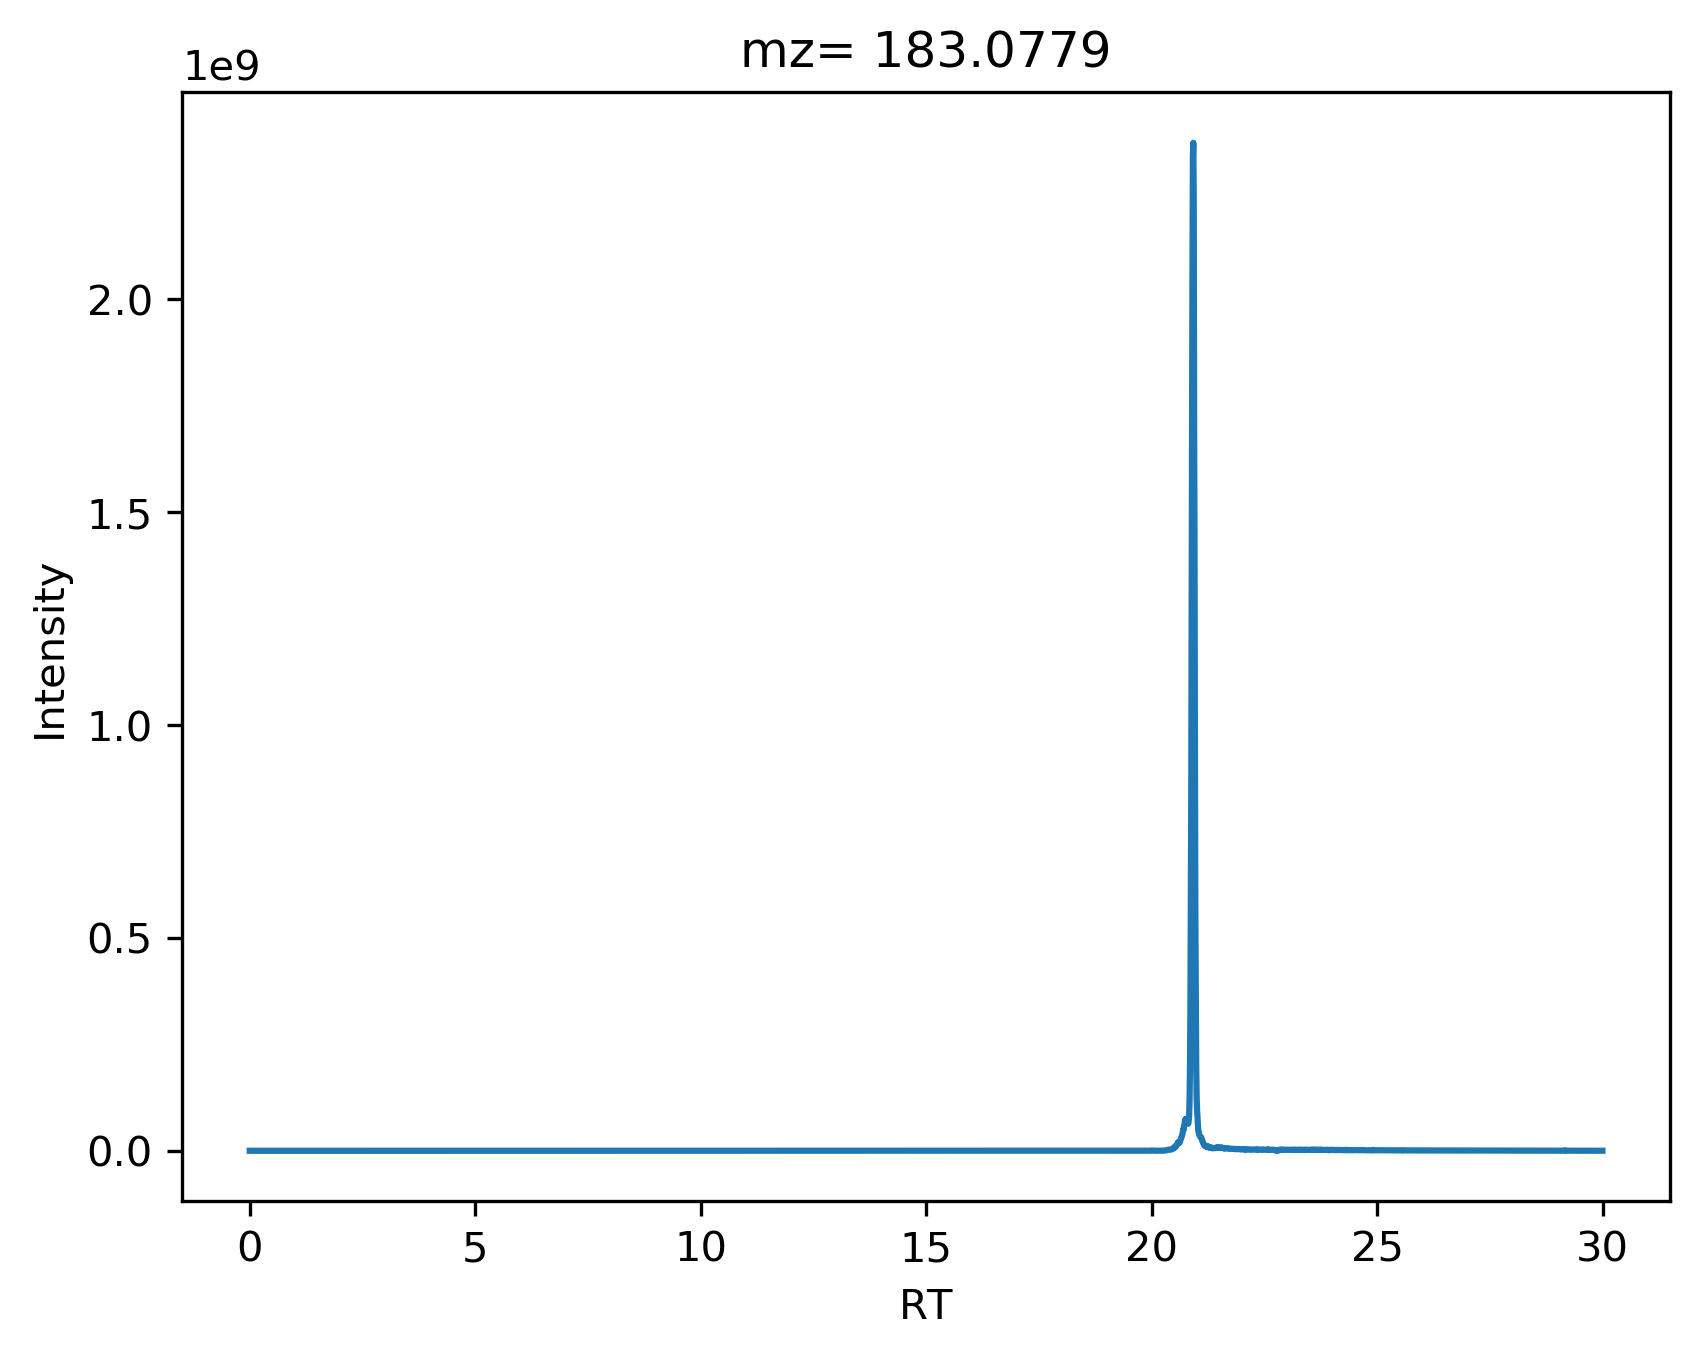

In [30]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(dpi=300)
plt.plot(EIC["rt_times"], EIC["tracks"][4435][1])
plt.xlabel("RT")
plt.ylabel("Intensity")
plt.title("mz= " + str('%.4f'%EIC["tracks"][1034][0]))

Peak Detection

In [26]:
min_peak_height = estimate_min_peak_height(mzml_path, EIC)
alldata,feature=Peaks(track_mass = EIC, min_peak_height = min_peak_height, goodness_fitting = 0.5, s_n = 10, peak_width = 6)

Peak detection:: 100%|██████████| 16592/16592 [11:25<00:00, 24.20it/s]


In [27]:
import pandas as pd
for i in feature :
    i[2]=ms1_["rt"][i[2]]
    i[3]=ms1_["rt"][i[3]]
    i[4]=ms1_["rt"][i[4]]
Feature_df=pd.DataFrame(feature,columns=["mz","index","RT","RT_left","RT_right","Height","goodness_fitting","area","SN"])
Feature_df

,mz,index,RT,RT_left,RT_right,Height,goodness_fitting,area,SN
0,100.064545,2,17.815487,17.722955,17.888382,5.411171e+05,0.828807,5.706517e+06,197.116035
1,100.112007,5,2.055819,2.023515,2.171175,1.323079e+06,0.893033,1.790859e+07,22.157846
2,100.509926,7,2.077213,2.058125,2.189701,2.707563e+06,0.830668,1.109793e+07,83.739636
3,100.696777,8,25.051221,24.967696,25.171730,9.131507e+06,0.994278,5.951459e+07,1017.588191
4,100.807899,12,25.051221,24.967696,25.171730,7.993133e+06,0.994533,5.179774e+07,960.885483
...,...,...,...,...,...,...,...,...,...
11639,1193.348755,16584,24.197768,24.160732,24.253211,4.633000e+05,0.953438,2.430352e+06,168.769116
11640,1194.323853,16586,21.730703,21.703037,21.777033,2.001711e+05,0.743026,1.045290e+06,72.917539
11641,1194.817383,16588,23.966276,23.929516,24.058528,1.962699e+06,0.976779,9.584767e+06,714.964196
11642,1195.820068,16589,23.966276,23.920264,24.030821,1.168123e+06,0.910864,7.384599e+06,425.519288


In [28]:
Feature_df.to_csv(r".\data\TCSP.csv")